### 1. Import libraries

In [1]:
import os 
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

### 2. Define dataset paths

In [2]:
PROJECT_ROOT = Path('..')
DATA_DIR = PROJECT_ROOT/'data'/'raw'
TRAIN_DIR = DATA_DIR/'Training'
TEST_DIR = DATA_DIR/'Testing'

print("Training directory:", TRAIN_DIR.resolve())
print("Testing directory:", TEST_DIR.resolve())

Training directory: C:\Projects\BrainTumorAI\data\raw\Training
Testing directory: C:\Projects\BrainTumorAI\data\raw\Testing


### 3. Check the classes

In [3]:
classes = sorted([
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
])

print('Classes: ')
for i, class_name in enumerate(classes):
    print(f'{i}: {class_name}')

Classes: 
0: glioma
1: meningioma
2: notumor
3: pituitary


### 4. Count training and testing images

In [4]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def count_images(directory):
    counts = {}

    for class_dir in directory.iterdir():
        if class_dir.is_dir():
            count = sum(
                1
                for file in class_dir.iterdir()
                if file.suffix.lower() in IMAGE_EXTENSIONS
            )

            counts[class_dir.name] = count

    return counts

traning_counts = count_images(TRAIN_DIR)
testing_counts = count_images(TEST_DIR)

print("Training:")
for class_name, count in traning_counts.items():
    print(f'{class_name}: {count}')

print("Testing:")
for class_name, count in testing_counts.items():
    print(f'{class_name}: {count}')


Training:
glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400
Testing:
glioma: 400
meningioma: 400
notumor: 400
pituitary: 400


### 5. Total images

In [6]:
total_train = sum(traning_counts.values())
total_test = sum(testing_counts.values())
total_images = total_train + total_test

print("Total training images:", total_train)
print("Total testing images:", total_test)
print("Total images:", total_images)

Total training images: 5600
Total testing images: 1600
Total images: 7200


### 6. Class distribution

In [8]:
distribution = pd.DataFrame({
    'Class': classes,
    'Training': [traning_counts.get(c,0) for c in classes],
    'Testing': [testing_counts.get(c,0) for c in classes]
})

distribution

,Class,Training,Testing
0,glioma,1400,400
1,meningioma,1400,400
2,notumor,1400,400
3,pituitary,1400,400


### 7. Visualize class distribution

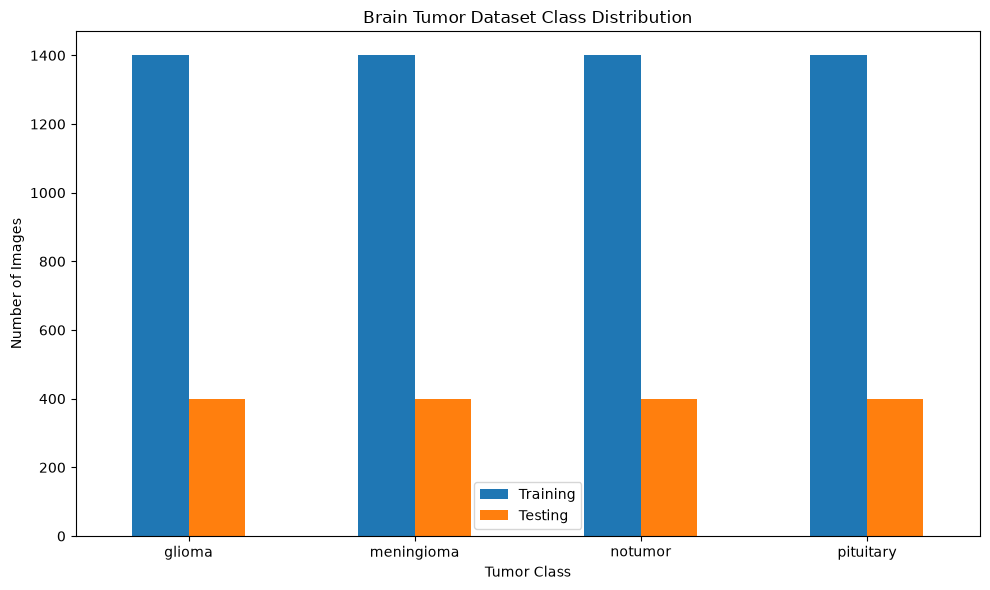

In [9]:
distribution.set_index('Class').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Brain Tumor Dataset Class Distribution")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 8. Check image dimensions

In [10]:
def get_image_files(directory):
    files = []

    for class_dir in directory.iterdir():
        if class_dir.is_dir():
            for file in class_dir.iterdir():
                if file.suffix.lower() in IMAGE_EXTENSIONS:
                    files.append(file)

    return files

In [11]:
train_files = get_image_files(TRAIN_DIR)

print("Number of training images:", len(train_files))

Number of training images: 5600


In [12]:
dimensions = []

for file in train_files:
    try:
        with Image.open(file) as img:
            dimensions.append(img.size)
    except Exception:
        pass

dimension_counts = Counter(dimensions)

print('Number of unique image dimensions: ', len(dimension_counts))

for dimension, count in dimension_counts.most_common(10):
    print(f'{dimension}: {count} images')

Number of unique image dimensions:  381
(512, 512): 4012 images
(225, 225): 253 images
(630, 630): 69 images
(201, 251): 40 images
(236, 236): 39 images
(442, 442): 38 images
(150, 198): 33 images
(232, 217): 32 images
(228, 221): 32 images
(428, 417): 31 images


### 9. Check corrupted images

In [13]:
def check_corrupted_images(directory):
    corrupted = []

    for file in get_image_files(directory):
        try:
            with Image.open(file) as img:
                img.verify()
        except Exception:
            corrupted.append(file)

    return corrupted

In [14]:
corrupted_train = check_corrupted_images(TRAIN_DIR)
corrupted_test = check_corrupted_images(TEST_DIR)

print("Corrupted training images:", len(corrupted_train))
print("Corrupted testing images:", len(corrupted_test))

Corrupted training images: 0
Corrupted testing images: 0


### 10. Display sample MRI images

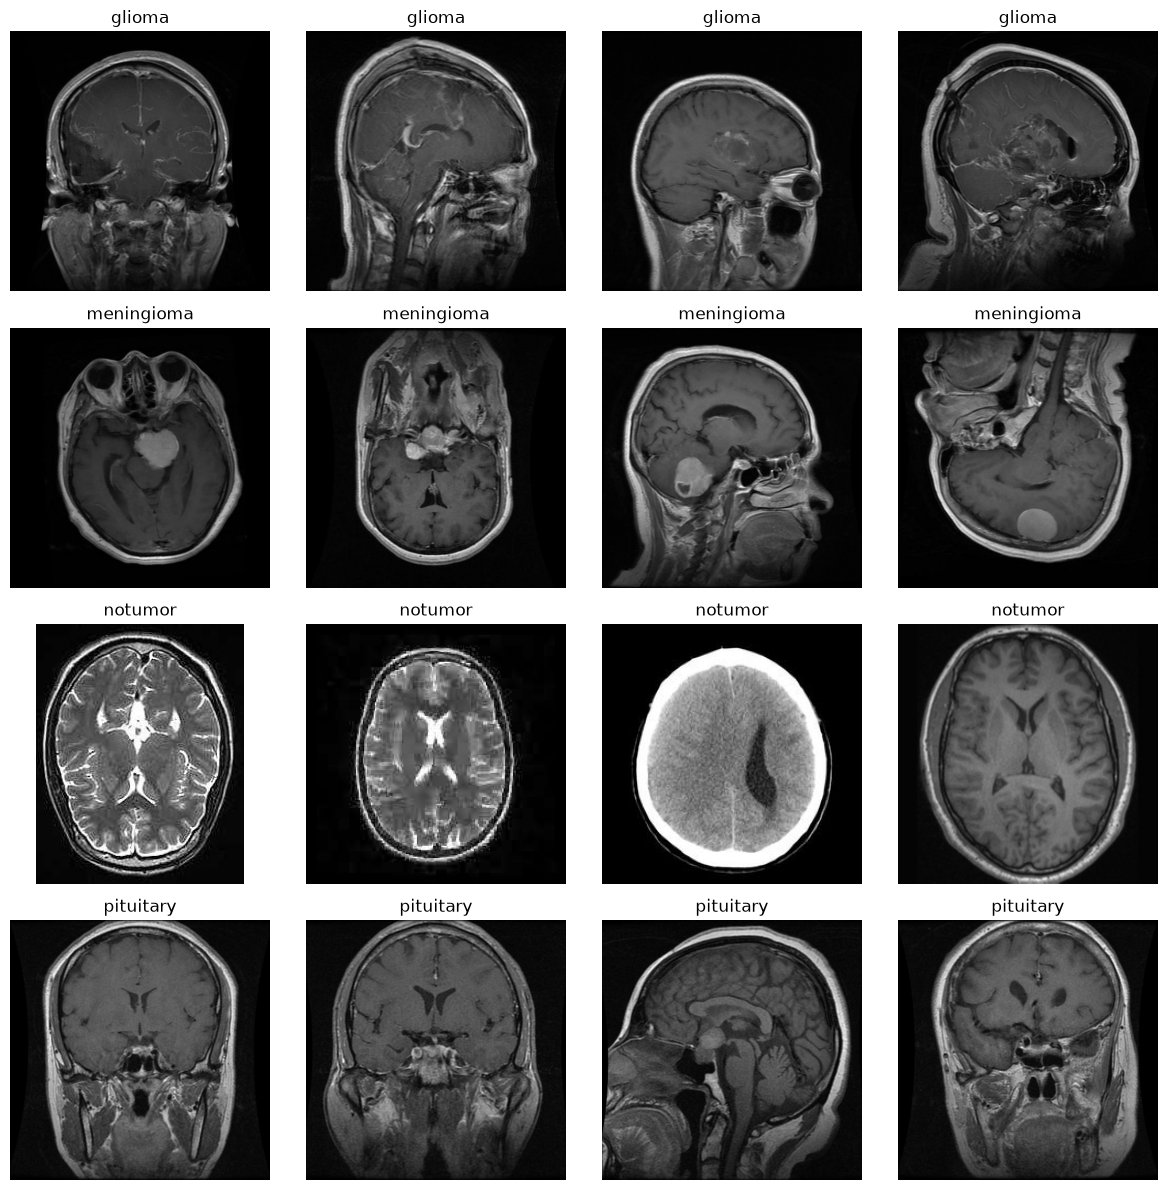

In [19]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12)
)

for row, class_name in enumerate(classes):
    class_dir = TRAIN_DIR / class_name
    
    image_files = [
        file for file in class_dir.iterdir()
        if file.suffix.lower() in IMAGE_EXTENSIONS
    ]
    
    for col, file in enumerate(image_files[:4]):
        with Image.open(file) as img:
            axes[row, col].imshow(img, cmap="gray")
        
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### 11. Create a dataset summary

In [20]:
summery = {
    'Total Images': total_images,
    'Training Images': total_train,
    'Testing Images': total_test,
    'Number of Classes': len(classes),
    'Corrupted Training': len(corrupted_train),
    'Corrupted Testing': len(corrupted_test),
    'Unique Image Dimensions': len(dimension_counts)
}

summery_df = pd.DataFrame(
    summery.items(),
    columns=['Metric', 'Value']
)

summery_df

,Metric,Value
0,Total Images,7200
1,Training Images,5600
2,Testing Images,1600
3,Number of Classes,4
4,Corrupted Training,0
5,Corrupted Testing,0
6,Unique Image Dimensions,381
